In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

In [2]:
train = pd.read_parquet("../data/processed/train.parquet")
test = pd.read_parquet("../data/processed/test.parquet")
prod_sim = pd.read_parquet("../data/processed/production_sim.parquet")

print(f"Train: {train.shape}")
print(f"Test: {test.shape}")
print(f"Prod sim: {prod_sim.shape}")

Train: (199364, 31)
Test: (56961, 31)
Prod sim: (28482, 31)


In [3]:
train

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199359,132927.0,-0.891484,0.017809,3.078285,0.292308,-0.808503,2.322562,-1.165476,-0.260185,0.057021,0.561998,-0.552186,0.965090,1.022840,-1.682989,-2.064727,-1.995109,0.127394,2.336763,0.628318,-0.256853,0.446677,0.107023,-0.374529,0.362141,0.536869,-0.204159,0.357010,-0.071318,25.00,0
199360,132927.0,1.921305,0.395242,-2.318680,1.398477,1.033023,-0.642820,0.629670,-0.211760,-0.178606,-0.215139,1.228539,0.846483,-0.126417,-0.838000,-1.050579,-0.049650,0.752611,0.492287,-0.168052,-0.133742,0.037927,0.218286,-0.030503,0.589564,0.442069,-0.546391,-0.009510,-0.025723,40.46,0
199361,132927.0,-0.638489,0.057029,1.022120,-1.267570,0.573539,0.253991,-0.351760,0.227176,-1.562525,-0.448122,1.102148,-0.268560,1.078835,-2.145878,0.059130,1.431000,1.366074,0.335253,1.743075,0.541960,0.311661,0.787535,-0.433117,0.161191,0.591464,0.193631,0.072301,0.100244,22.00,0
199362,132928.0,-1.383590,-5.632354,-4.637217,1.364093,-0.042684,1.207176,2.887418,-0.417337,-0.258312,-0.758541,0.055962,0.194616,-0.528698,1.441682,1.174796,-1.759054,1.181053,-2.221707,-1.978109,3.161848,1.414935,0.395609,-1.539984,-0.423408,-0.330285,0.929866,-0.412846,0.196356,1745.40,0


Fraud rate: 0.1926%
Class
0    198980
1       384
Name: count, dtype: int64


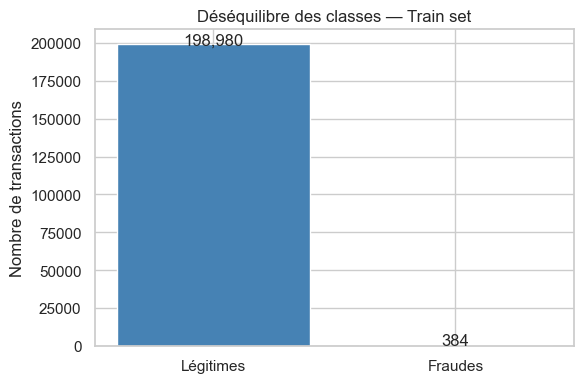

In [4]:
fraud_counts = train['Class'].value_counts()
fraud_rate = train['Class'].mean()

print(f"Fraud rate: {fraud_rate:.4%}")
print(fraud_counts)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Légitimes', 'Fraudes'], fraud_counts.values, color=['steelblue', 'crimson'])
ax.set_title("Déséquilibre des classes — Train set")
ax.set_ylabel("Nombre de transactions")
for i, v in enumerate(fraud_counts.values):
    ax.text(i, v + 100, f'{v:,}', ha='center')
plt.tight_layout()
plt.show()

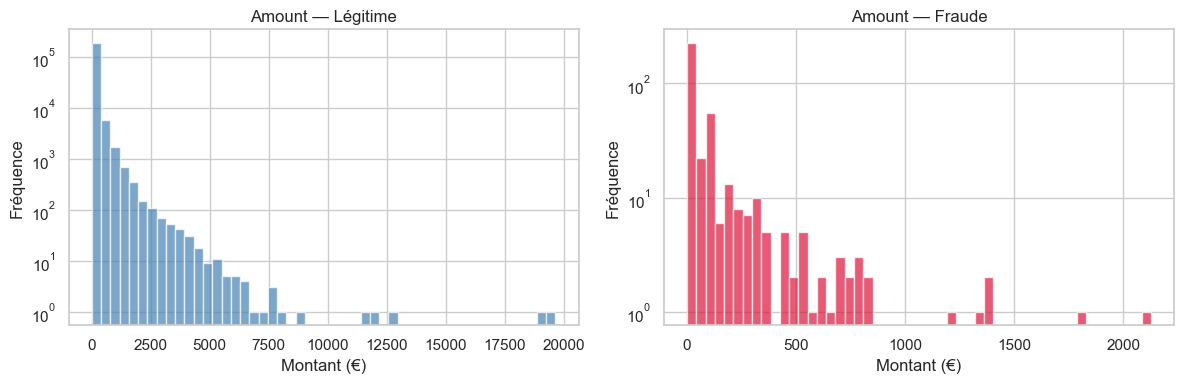

          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      198980.0   89.72  248.91  0.0  5.99  23.00   79.15  19656.53
1         384.0  118.65  248.77  0.0  1.00  11.86  104.22   2125.87


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, label, color in zip(axes, [0, 1], ['steelblue', 'crimson']):
    data = train[train['Class'] == label]['Amount']
    ax.hist(data, bins=50, color=color, alpha=0.7)
    ax.set_title(f"Amount — {'Fraude' if label else 'Légitime'}")
    ax.set_xlabel("Montant (€)")
    ax.set_ylabel("Fréquence")
    ax.set_yscale('log')

plt.tight_layout()
plt.show()

print(train.groupby('Class')['Amount'].describe().round(2))

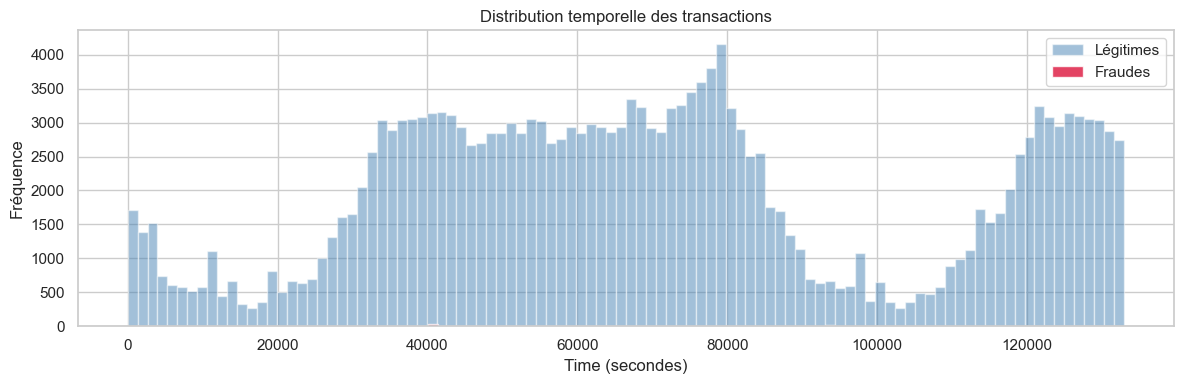

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(train[train['Class'] == 0]['Time'], bins=100, alpha=0.5, label='Légitimes', color='steelblue')
ax.hist(train[train['Class'] == 1]['Time'], bins=100, alpha=0.8, label='Fraudes', color='crimson')
ax.set_title("Distribution temporelle des transactions")
ax.set_xlabel("Time (secondes)")
ax.set_ylabel("Fréquence")
ax.legend()
plt.tight_layout()
plt.show()

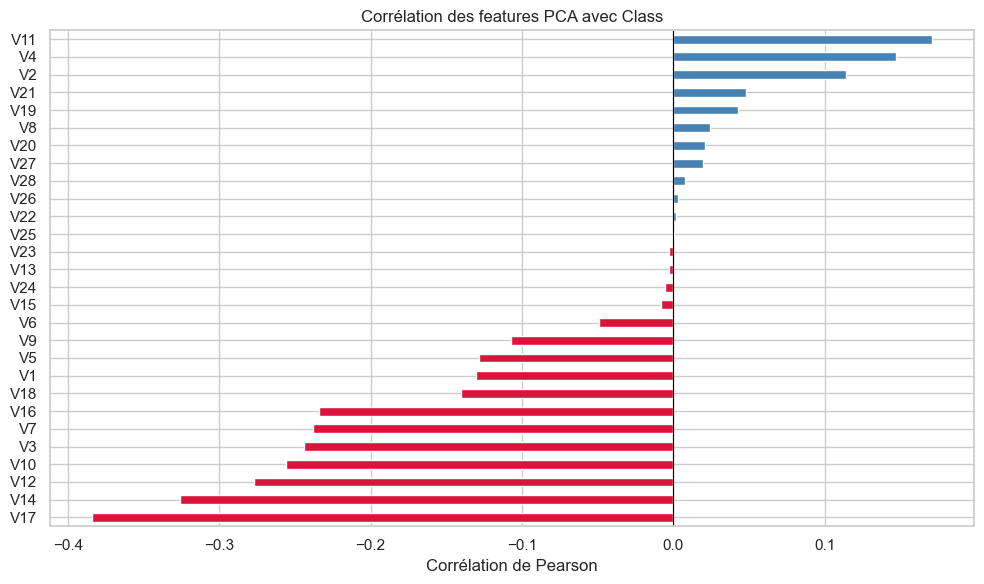

In [7]:
features = [f'V{i}' for i in range(1, 29)]
correlations = train[features + ['Class']].corr()['Class'].drop('Class').sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
correlations.plot(kind='barh', ax=ax, color=['crimson' if x < 0 else 'steelblue' for x in correlations])
ax.set_title("Corrélation des features PCA avec Class")
ax.set_xlabel("Corrélation de Pearson")
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [8]:
print("=== Comparaison train vs prod_sim (drift simulé) ===\n")

for col in ['Amount', 'V1', 'V3', 'V4', 'V10', 'V14']:
    train_mean = train[col].mean()
    prod_mean = prod_sim[col].mean()
    delta = abs(prod_mean - train_mean) / (abs(train_mean) + 1e-9)
    print(f"{col:10s} | Train mean: {train_mean:8.4f} | Prod mean: {prod_mean:8.4f} | Delta: {delta:.2%}")

=== Comparaison train vs prod_sim (drift simulé) ===

Amount     | Train mean:  89.7712 | Prod mean:  69.7518 | Delta: 22.30%
V1         | Train mean:  -0.1054 | Prod mean:   0.2529 | Delta: 339.93%
V3         | Train mean:   0.3208 | Prod mean:  -0.7245 | Delta: 325.85%
V4         | Train mean:   0.0755 | Prod mean:  -0.1720 | Delta: 327.90%
V10        | Train mean:  -0.0112 | Prod mean:  -0.0026 | Delta: 76.88%
V14        | Train mean:   0.0508 | Prod mean:  -0.1191 | Delta: 334.55%


In [9]:
alpha = 0.3
significant = correlations[correlations.abs() > alpha]
top_corr = significant.abs().nlargest(3).index.tolist()

print(f"""
CONCLUSIONS EDA
===============
1. Déséquilibre massif : {fraud_rate:.4%} de fraudes → nécessite scale_pos_weight + SMOTE
2. Amount très skewed → log-transform dans le preprocessing
3. {len(significant)} features avec |corrélation| > {alpha} : {', '.join(top_corr)} parmi les plus fortes
4. Drift simulé visible sur Amount et certaines features V entre train et prod_sim
5. Pas de valeurs manquantes → pipeline simplifié
""")
print(f"Valeurs manquantes : {train.isnull().sum().sum()}")


CONCLUSIONS EDA
1. Déséquilibre massif : 0.1926% de fraudes → nécessite scale_pos_weight + SMOTE
2. Amount très skewed → log-transform dans le preprocessing
3. 2 features avec |corrélation| > 0.3 : V17, V14 parmi les plus fortes
4. Drift simulé visible sur Amount et certaines features V entre train et prod_sim
5. Pas de valeurs manquantes → pipeline simplifié

Valeurs manquantes : 0
